In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Kelas B_CO2 Emissions by Car.csv', sep=';')

df.head()

,MODEL_YEAR,MAKE,MODEL,VEHICLE CLASS,ENGINE_SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL_CONSUMPTION*,CO2_EMISSIONS
0,2001,ACURA,1.7EL,COMPACT,1.7,4,A4,X,9.3,191
1,2001,ACURA,1.7EL,COMPACT,1.7,4,M5,X,8.9,191
2,2001,ACURA,3.2CL,COMPACT,3.2,6,AS5,Z,13.7,265
3,2001,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.8,267
4,2001,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301


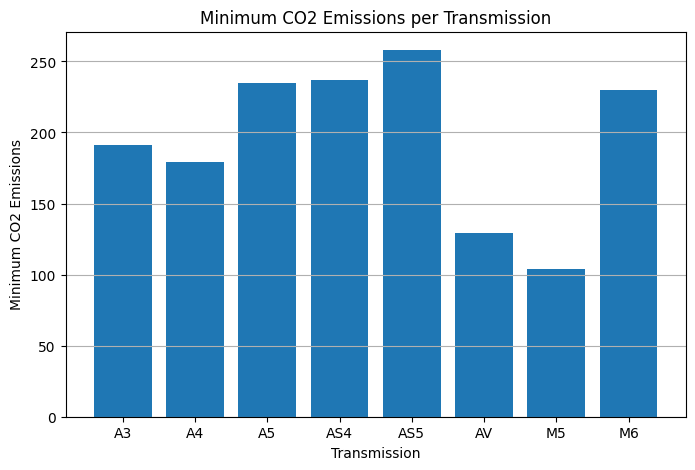

In [17]:
#Kategori A (Agregasi)
min_co2 = df.groupby('TRANSMISSION', as_index=False)['CO2_EMISSIONS'].min()

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(
    min_co2['TRANSMISSION'],
    min_co2['CO2_EMISSIONS']
)

ax.set_title('Minimum CO2 Emissions per Transmission')
ax.set_xlabel('Transmission')
ax.set_ylabel('Minimum CO2 Emissions')
ax.grid(axis='y')

plt.show()

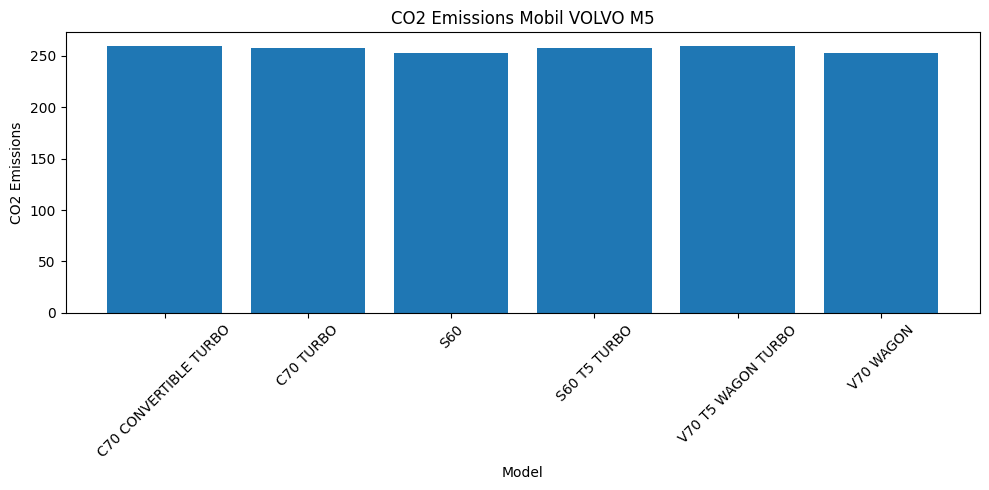

In [14]:
#Kategori B (Tren/Filter)
volvo_m5 = df[
    (df['MAKE'] == 'VOLVO') &
    (df['TRANSMISSION'] == 'M5')
]

fig, ax = plt.subplots(figsize=(10,5))

ax.bar(
    volvo_m5['MODEL'],
    volvo_m5['CO2_EMISSIONS']
)

ax.set_title('CO2 Emissions Mobil VOLVO M5')
ax.set_xlabel('Model')
ax.set_ylabel('CO2 Emissions')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

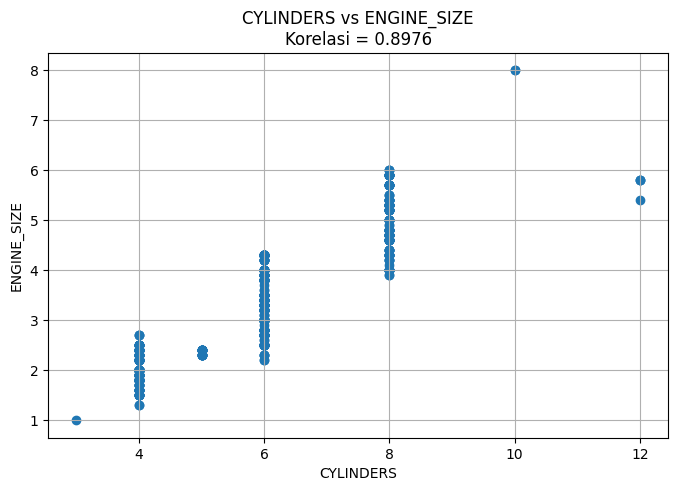

In [15]:
#Kategori C (Korelasi)
corr = df['CYLINDERS'].corr(df['ENGINE_SIZE'])

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(
    df['CYLINDERS'],
    df['ENGINE_SIZE']
)

ax.set_title(
    f'CYLINDERS vs ENGINE_SIZE\nKorelasi = {corr:.4f}'
)

ax.set_xlabel('CYLINDERS')
ax.set_ylabel('ENGINE_SIZE')

ax.grid(True)

plt.show()

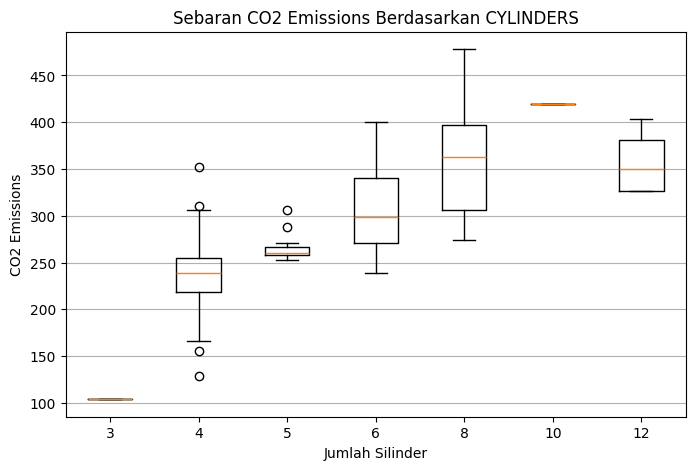

In [18]:
#Kategori D (Distribusi)
groups = [
    group['CO2_EMISSIONS'].values
    for _, group in df.groupby('CYLINDERS')
]

labels = sorted(df['CYLINDERS'].unique())

fig, ax = plt.subplots(figsize=(8,5))

ax.boxplot(
    groups,
    tick_labels=labels
)

ax.set_title(
    'Sebaran CO2 Emissions Berdasarkan CYLINDERS'
)

ax.set_xlabel('Jumlah Silinder')
ax.set_ylabel('CO2 Emissions')

ax.grid(axis='y')

plt.show()